# imports

In [1]:
%load_ext autoreload
%autoreload 2

import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [ ]:
import numpy as np

# the following imports are for the classifier code, written by Ivan Shalashilinsky
# from _binary_labels import binary_to_pm1, create_class_labels
# from suN_mps_classifier import optimise_classifier_mps


from my_functions import (
    generalized_reconstruction,
    left_to_right_sweep,
    evaluate_accuracy,+
    plot_ensemble_performance,
    count_params,
    truncate_mpo_via_gauge,
)


import matplotlib.pyplot as plt
import os
from pathlib import Path

import itertools
import math

import time
from ncon import ncon
from scipy.linalg import svd, norm

from matplotlib.colors import TwoSlopeNorm
from joblib import Parallel, delayed

from sklearn.datasets import fetch_openml


---

# Construction of the Prototype (Equal Weights)

Tensor construction for summing $N_{batch}$ states.

### 1. First Site ($n=1$)
The tensor for the first site is constructed by concatenating the first tensors of all $N_{batch}$ states into a row vector.

$$\mathcal{A}_{1}^{\sigma_{1}} = \left( \underline{A}_{1}^{\sigma_{1}, 1}, \: \underline{A}_{1}^{\sigma_{1}, 2}, \: \dots, \: \underline{A}_{1}^{\sigma_{1}, N_{batch}} \right)$$

where $\underline{A}_{1}^{\sigma_{1}, i}$ is a vector containing every single scalar component $= A^{\sigma_1}_{1 \ 1} , A^{\sigma_1}_{1 \ 2} , ... , A^{\sigma_1}_{1 \ D_1}$, where $D_1$ is the auxiliary bond dimension.

### 2. General Site ($n$)
The combined tensor is the block diagonal sum of the individual tensors.

$$\mathcal{A}_{n}^{\sigma_n} = 
\begin{pmatrix}
\underline{\underline{A}}_{n}^{\sigma_n, 1} & 0 & \cdots & 0 \\
0 & \underline{\underline{A}}_{n}^{\sigma_n, 2} & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & \underline{\underline{A}}_{n}^{\sigma_n, N_{batch}}
\end{pmatrix}$$

### 3. Last Site ($n = N_{batch}$)
The tensor for the final site is constructed by concatenating the last tensors of all $N_{batch}$ states into a column vector.

$$\mathcal{A}_{N_{batch}}^{\sigma_{N_{batch}}} = 
\begin{pmatrix}
\underline{A}_{N_{batch}}^{\sigma_{N_{batch}}, 1} \\
\underline{A}_{N_{batch}}^{\sigma_{N_{batch}}, 2} \\
\vdots \\
\underline{A}_{N_{batch}}^{\sigma_{N_{batch}}, N_{batch}}
\end{pmatrix}$$

In [3]:
# debug giv check
print(f"script running from: {os.getcwd()}")
# SCRIPT_DIR = Path(__file__).parent
SCRIPT_DIR = Path.cwd()
save_mnist_dir = SCRIPT_DIR / "mnist_clusters"
print("the dir im in:", SCRIPT_DIR)

script running from: c:\Users\alios\OneDrive - University College London\Desktop\UCL\Year4\year4_project\codes
the dir im in: c:\Users\alios\OneDrive - University College London\Desktop\UCL\Year4\year4_project\codes


# Train MPO

In [ ]:
# part of the code to load teh data and train the model, This part of teh code is written by Ivan Shalashilinsky


# bond_dim_data = 8
# n_qubits = 10
# # load the data
# cluster_list_train = np.load(
#     save_mnist_dir
#     / f"mnist_cluster_list_bond_dim_{bond_dim_data}_{n_qubits}_qubits_train.npz",
#     allow_pickle=True,
# )["cluster_list"]
# cluster_list_test = np.load(
#     save_mnist_dir
#     / f"mnist_cluster_list_bond_dim_{bond_dim_data}_{n_qubits}_qubits_test.npz",
#     allow_pickle=True,
# )["cluster_list"]
# class_labels_train = [
#     np.full(len(cluster), i) for i, cluster in enumerate(cluster_list_train)
# ]


# bond_dim = [10]
# # # bond_dim = [30, 256]


# lengthscale_prefactor = 0.6
# learning_rate = 0.015
# n_iterations = 5

# batch_sizes = [10, 10, 10]
# print(f"prefactor: {lengthscale_prefactor}")
# accuracy_all = {
#     "classical": np.zeros((len(bond_dim), n_iterations)),
#     "quantum": np.zeros((len(bond_dim), n_iterations)),
# }

# N_samples_list = [len(cluster) for cluster in cluster_list_train]

# class_labels = create_class_labels(N_samples_list)
# binary_labels_train = binary_to_pm1(class_labels)


# n_classes = 10
# for optimisation in ["classical"]:
#     for i, dim in enumerate(bond_dim):
#         print(f"optimisation: {optimisation}, bond dimension: {dim}")
#         opt_hyperparams = {
#             "bond_dim": dim,
#             "lengthscale_prefactor": lengthscale_prefactor,
#             "learning_rate": learning_rate,
#             "n_iterations": n_iterations,
#             "batch_sizes": batch_sizes,
#             "optimisation": optimisation,
#             "Z0": True,  # 'Z0' : False # Unsure how to implement this for now
#         }

#         classifier_mpo, accuracy = optimise_classifier_mps(
#             cluster_list_train[:n_classes],
#             class_labels=class_labels[:n_classes],
#             opt_hyperparams=opt_hyperparams,
#         )
#         accuracy_all[optimisation][i] = accuracy
#         np.savez(
#             SCRIPT_DIR
#             / f"mnist_tensors_{dim}_{n_classes}_classes_zweight_{n_qubits}_qubits.npz",
#             accuracy_all=accuracy_all,
#             opt_hyperparams=opt_hyperparams,
#             classifier_mpo=np.array(classifier_mpo, dtype=object),
#         )


Accuracy of the saved model for bond dim 256: `83%`, 4 iterations


Accuracy of the saved model for bond dim 10: `73.3%`, 5 iterations

Accuracy of the saved model for bond dim 30: `82.3%`, 5 iterations

Accuracy of the saved model for bond dim 40: `82.9%`, 5 iterations

## load MPO and testing digits
Structure of the testing images is the following. It's a cluster of 10 classes with 100 digits each, the digits are encoded as mps.

In [5]:
bond_dim = [256]
# bond_dim = [30]
n_classes = 10
file_path = f"mnist_tensors_{bond_dim[0]}_{n_classes}_classes_zweight.npz"

# file_path = f"mnist_tensors_{bond_dim[0]}_{n_classes}_classes_zweight_10_qubits.npz"
data = np.load(file_path, allow_pickle=True)

# access mpo
mpo_tensor_list = data["classifier_mpo"]
print(f"shape mpo: {mpo_tensor_list.shape}")


# upload data for testing
# SCRIPT_DIR = Path(__file__).parent
# SCRIPT_DIR = Path.cwd()
# save_mnist_dir = SCRIPT_DIR / "mnist_clusters"

bond_dim_data = 8
n_qubits = 10


cluster_list_test = np.load(
    save_mnist_dir
    / f"mnist_cluster_list_bond_dim_{bond_dim_data}_{n_qubits}_qubits_test.npz",
    allow_pickle=True,
)["cluster_list"]


shape mpo: (5,)


In [6]:
# shape of each mps tensor
for i, M_site in enumerate(mpo_tensor_list):
    print(f"Site {i}, shape: {M_site.shape}")

Site 0, shape: (10, 4, 256)
Site 1, shape: (256, 4, 64)
Site 2, shape: (64, 4, 16)
Site 3, shape: (16, 4, 4)
Site 4, shape: (4, 4, 1)


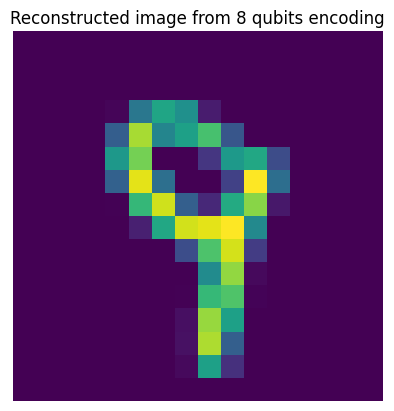

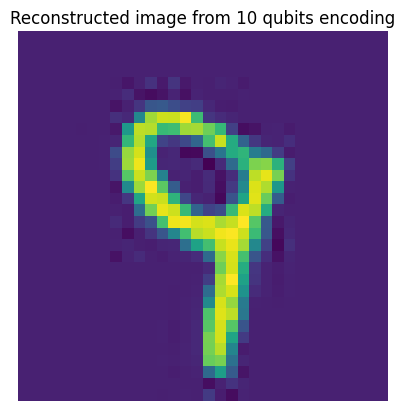

In [7]:
# see difference between 8 and 10 qubits encoding


cluster_list_test_8qubits = np.load(
    save_mnist_dir / f"mnist_cluster_list_bond_dim_8_8_qubits_test.npz",
    allow_pickle=True,
)["cluster_list"]

cluster_list_test_10qubits = np.load(
    save_mnist_dir / f"mnist_cluster_list_bond_dim_8_10_qubits_test.npz",
    allow_pickle=True,
)["cluster_list"]


# select one image from each test set
test_image1_mps = cluster_list_test_8qubits[9][0]
test_image2_mps = cluster_list_test_10qubits[9][0]

# reconstruct image from mps
reconstructed_image1 = generalized_reconstruction(
    test_image1_mps, 0, transpose_result=True
)
reconstructed_image2 = generalized_reconstruction(
    test_image2_mps, 0, transpose_result=True
)

plt.title("Reconstructed image from 8 qubits encoding")
plt.imshow(reconstructed_image1)
plt.axis("off")
plt.show()

plt.title("Reconstructed image from 10 qubits encoding")
plt.imshow(reconstructed_image2)
plt.axis("off")
plt.show()

In [8]:
bond_dim = [256]
n_classes = 10
file_path = f"mnist_tensors_{bond_dim[0]}_{n_classes}_classes_zweight_10_qubits.npz"
data = np.load(file_path, allow_pickle=True)

# access mpo
mpo_tensor_list = data["classifier_mpo"]
print(f"shape mpo: {mpo_tensor_list.shape}")


for i, M_site in enumerate(mpo_tensor_list):
    print(f"Site {i}, shape: {M_site.shape}")


shape mpo: (5,)
Site 0, shape: (10, 4, 256)
Site 1, shape: (256, 4, 64)
Site 2, shape: (64, 4, 16)
Site 3, shape: (16, 4, 4)
Site 4, shape: (4, 4, 1)


# Mask (lowest features)

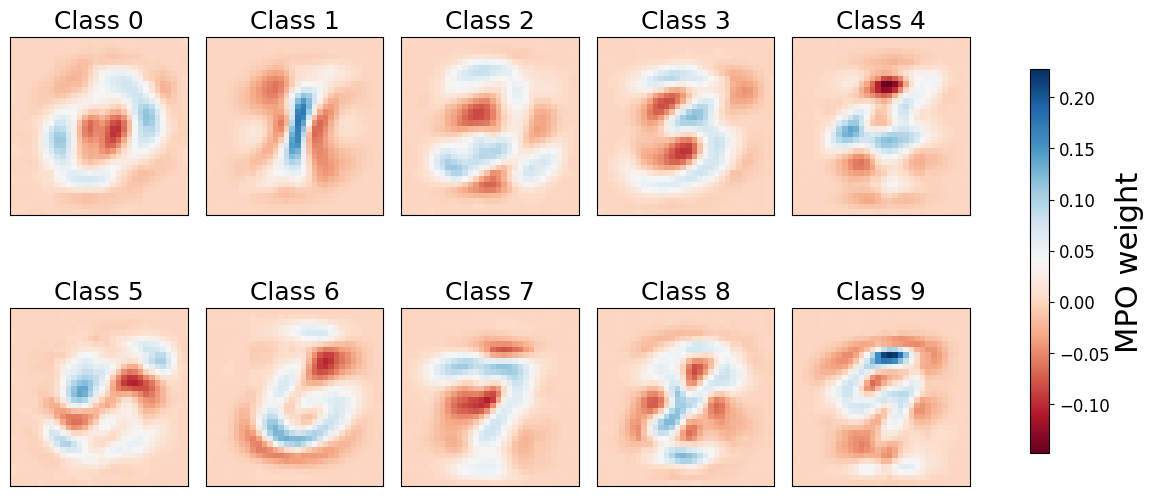

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
# fig.suptitle("32x32 Masks from MPO classifier", fontsize=16, x=0.4)

class_projectors = []
num_features = mpo_tensor_list[0].shape[0]

max_plots = 10
for f in range(min(num_features, max_plots)):
    img = generalized_reconstruction(
        mpo_tensor_list, selection_index=f, transpose_result=True
    )
    class_projectors.append(img)

v_min = np.min(class_projectors)
v_max = np.max(class_projectors)

axes_flat = axes.flatten()

mask_mpo = []

for i, ax in enumerate(axes_flat):
    if i < len(class_projectors):
        mask_i = class_projectors[i]
        mask_mpo.append(mask_i)

        h, w = mask_i.shape

        im = ax.imshow(mask_i, cmap="RdBu", vmin=v_min, vmax=v_max)

        ax.tick_params(
            which="major", bottom=False, left=False, labelbottom=False, labelleft=False
        )

        ax.set_title(f"Class {i}", fontsize=18)
    else:
        ax.axis("off")

fig.subplots_adjust(
    left=0.05,
    right=0.85,
    bottom=0.05,
    top=0.85,
    wspace=0.1,
    hspace=0.3,
)

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
cbar.set_label("MPO weight", fontsize=22)
cbar.ax.tick_params(labelsize=12)
plt.savefig("plots/class_projectors.png", dpi=600, bbox_inches="tight")
plt.show()

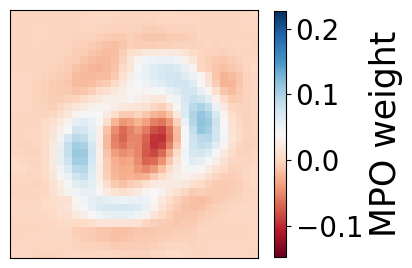

In [10]:
# mask 1 for report
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
im = ax.imshow(mask_mpo[0], cmap="RdBu", vmin=v_min, vmax=v_max)
ax.tick_params(
    which="major", bottom=False, left=False, labelbottom=False, labelleft=False
)
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("MPO weight", fontsize=25)
cbar.ax.tick_params(labelsize=20)
plt.savefig("plots/class_projectors_mask0.png", dpi=600, bbox_inches="tight")
plt.show()


In [11]:
mask = mask_mpo[0]

print("L2 norm:", np.linalg.norm(mask))
print("L1 norm:", np.linalg.norm(mask, ord=1))
print("Is L2-normalised (norm approx 1):", np.isclose(np.linalg.norm(mask), 1.0))


L2 norm: 1.0000000000000007
L1 norm: 1.1343730664974214
Is L2-normalised (norm approx 1): True


The below code idea was taken from: 

https://stats.stackexchange.com/questions/426873/how-does-a-simple-logistic-regression-model-achieve-a-92-classification-accurac


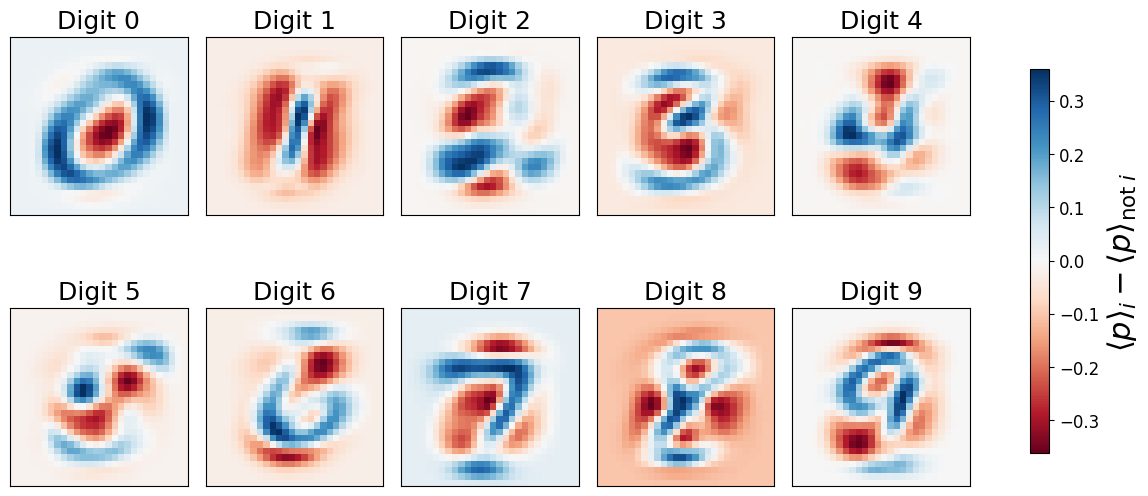

In [12]:
# get the data
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
y = y.astype(int)
X = X / 255.0

global_sum = np.sum(X, axis=0)
total_count = len(X)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# fig.suptitle(
#     r"$\langle \text{Class } i \rangle - \langle \text{Not Class i} \rangle$",
#     fontsize=16,
#     x=0.4,
# )
# store masks for each class
masks_mean = []

for i, ax in enumerate(axes.flat):
    idx = y == i
    count_in = np.sum(idx)

    # calculate mean for class i and mean for not class i
    sum_in = np.sum(X[idx], axis=0)
    mean_in = sum_in / count_in
    mean_out = (global_sum - sum_in) / (total_count - count_in)

    diff_img = mean_in - mean_out

    img_reshaped = diff_img.reshape(28, 28)
    im = ax.imshow(img_reshaped, cmap="RdBu")
    masks_mean.append(img_reshaped)

    # contour lines at zero to highlight the boundary
    # ax.contour(img_reshaped, levels=[0], colors="black", linewidths=0.5)

    ax.set_title(f"Digit {i}", fontsize=18)

    ax.tick_params(
        which="major", bottom=False, left=False, labelbottom=False, labelleft=False
    )

fig.subplots_adjust(
    left=0.05, right=0.85, bottom=0.05, top=0.85, wspace=0.1, hspace=0.3
)

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
cbar.set_label(
    r"$\langle p \rangle_i - \langle p \rangle_{\text{not} \; i}$", fontsize=22
)
cbar.ax.tick_params(labelsize=12)

plt.savefig("plots/mean_difference_images.png", dpi=600, bbox_inches="tight")
plt.show()

In [13]:
from scipy.ndimage import zoom

# overlap between class projectors and mean difference images
# zoom factor
factor = 32 / 28

similarities = []
for i in range(10):
    mpo_flat = mask_mpo[i].flatten()
    mean_flat = zoom(masks_mean[i], factor).flatten()
    cos = np.dot(mpo_flat, mean_flat) / (
        np.linalg.norm(mpo_flat) * np.linalg.norm(mean_flat)
    )
    similarities.append(cos)

print("Cosine similarities between MPO masks and mean difference images:")
for i, sim in enumerate(similarities):
    print(f"Class {i}: {sim:.4f}")


Cosine similarities between MPO masks and mean difference images:
Class 0: 0.9169
Class 1: 0.7056
Class 2: 0.9240
Class 3: 0.9023
Class 4: 0.7995
Class 5: 0.7770
Class 6: 0.9194
Class 7: 0.8134
Class 8: 0.9233
Class 9: 0.7585


In [14]:
def compute_overlap_for_mps(mps_bra, mps_ket):
    """compute inner product <mps_bra|mps_ket>."""
    # init environment
    env = np.eye(1, dtype=mps_bra[0].dtype)

    for A, B in zip(mps_bra, mps_ket):
        env = ncon([env, A.conj(), B], [[1, 2], [1, 3, -1], [2, 3, -2]])

    return env.item()

In [15]:
num_classes = 10
overlap_matrix = np.zeros((num_classes, num_classes))

for class_idx in range(num_classes):
    # get class projector from mpo
    t0_class = mpo_tensor_list[0][class_idx].reshape(1, 4, -1)

    # build full mps chain for this class
    mpo_class_mps = [t0_class] + [t.copy() for t in mpo_tensor_list[1:]]

    for digit_idx in range(num_classes):
        test_image_mps = cluster_list_test[digit_idx][1]

        overlap = compute_overlap_for_mps(mpo_class_mps, test_image_mps)
        overlap_matrix[class_idx, digit_idx] = overlap

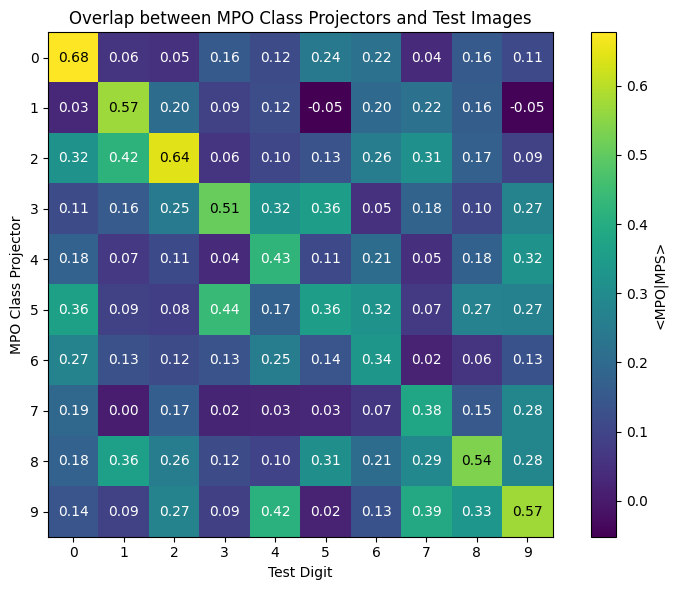

In [16]:
plt.figure(figsize=(8, 6))
plt.imshow(overlap_matrix, cmap="viridis", origin="upper")
plt.colorbar(label="<MPO|MPS>")
plt.xlabel("Test Digit")
plt.ylabel("MPO Class Projector")
plt.title("Overlap between MPO Class Projectors and Test Images")

# annotate grid
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(
            j,
            i,
            f"{overlap_matrix[i, j]:.2f}",
            ha="center",
            va="center",
            color="w" if overlap_matrix[i, j] < 0.5 else "k",
        )

plt.xticks(range(num_classes))
plt.yticks(range(num_classes))
plt.tight_layout()
plt.savefig("plots/mnist_mpo_mps_overlap.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
# raise SystemExit("Stopping execution here")

# Weighted motifs: 
## Make a right to left sweep 
We are interested in the motifs that contribute the most to the creation of the classifier, hence the ones that have larger weight (singular values). 

The MPO is constructed to be in right-canonical form, hence contracting the physical bonds from right to left will give us identity, the svd decomposition will give us singular value of 1.

To correctly find the weight of the motifs we need to convert the MPO in a mixed canonical form up to the site of interest. This is done by:

1. select a specific label (effectively selecting a specific class)
2. Apply a right to left sweep, to convert right canonical MPO into left canonical MPO up to a certain site.

### The code:
1. Density matrix ($\rho$)
Contract the accumulated Left Environment with the current site and its conjugate. This represents the overlap of the entire chain from site $0$ to $i$.
$$\rho = \text{ncon}([E, (A^{[i]})^*, A^{[i]}], \dots)$$
(Result is a square matrix on the Right Bond)

2. Diagonalize ($\rho$) <br>
Perform SVD on the density matrix
$$\rho = W \Lambda W^\dagger$$

3. Update Current Site ($A^{[i]}$)
$$\tilde{A}^{[i]} = A^{[i]} \cdot W$$

4. Push Gauge to Next Site ($A^{[i+1]}$)
$$\tilde{A}^{[i+1]} = W^\dagger \cdot A^{[i+1]}$$

5. Update Environment ($E_{\text{next}}$) <br>
Compute the environment for the next iteration using the updated current tensor.
$$E_{\text{next}} = \text{ncon}([E, (\tilde{A}^{[i]})^*, \tilde{A}^{[i]}], \dots)$$

In [18]:
# mpo_tensor_list_single_class = mpo_tensor_list[1]
for i in range(mpo_tensor_list.shape[0]):
    print(mpo_tensor_list[i].shape)

(10, 4, 256)
(256, 4, 64)
(64, 4, 16)
(16, 4, 4)
(4, 4, 1)


In [19]:
# get mpo for only class zero
mpo_single_class = []
for i in range(len(mpo_tensor_list)):
    if i == 0:
        first_tensor = mpo_tensor_list[i][2]
        first_tensor = first_tensor.reshape(
            1, first_tensor.shape[0], first_tensor.shape[1]
        )

        mpo_single_class.append(first_tensor)
    else:
        mpo_single_class.append(mpo_tensor_list[i])

for i in range(len(mpo_single_class)):
    print(mpo_single_class[i].shape)


# perform left to right sweep for testing
mpo_single_class_mixed_canonical, lambda_last_site, W_last = left_to_right_sweep(
    mpo_single_class, 2
)

(1, 4, 256)
(256, 4, 64)
(64, 4, 16)
(16, 4, 4)
(4, 4, 1)


In [20]:
# test that W_last is unitary
id_test = np.eye(W_last.shape[0])
ww = W_last @ W_last.conj().T
np.allclose(ww, id_test)

True

In [21]:
def plot_top_motifs(mpo_tensor_list, sweep_depth=2, top_k=4):
    """plot top_k motifs per class after sweeping to sweep_depth.
    The S spectrum shows up to 10 singular values but only top_k motifs are plotted."""
    # store motifs
    best_motif_array = []

    fig, axes = plt.subplots(
        10, top_k + 1, figsize=(top_k * 1.5, 12), constrained_layout=True
    )
    # fig.suptitle("Top Motifs per Class after Left-to-Right Sweep", fontsize=16)
    fig.get_layout_engine().set(w_pad=0.01, h_pad=0.01, hspace=0.01, wspace=0.07)

    for class_idx in range(10):
        t0_class = mpo_tensor_list[0][class_idx].reshape(1, 4, -1)
        mpo_class = [t0_class] + list(mpo_tensor_list[1:])

        mpo_swept, weights, _ = left_to_right_sweep(mpo_class, depth=sweep_depth)
        motif_chain = mpo_swept[sweep_depth:]

        # number of singular values to show in spectrum
        spectrum_n = min(10, len(weights))

        class_imgs = []
        class_weights = []

        for rank in range(top_k):
            base_img = generalized_reconstruction(
                motif_chain, selection_index=rank, transpose_result=True
            )
            weight = weights[rank]
            class_imgs.append(base_img)
            class_weights.append(weight)

        best_motif_array.append(class_imgs)

        valid_imgs = [img for img in class_imgs if img is not None]
        v_min = min(np.min(img) for img in valid_imgs)
        v_max = max(np.max(img) for img in valid_imgs)

        row_im = None
        title_size_tmp = 12
        for rank in range(top_k):
            ax = axes[class_idx, rank]
            img = class_imgs[rank]
            row_im = ax.imshow(img, cmap="viridis", vmin=v_min, vmax=v_max)

            title_size_main = 12
            title_size_sub = 8

            if rank == 0:
                ax.set_ylabel(
                    f"Class {class_idx}", fontsize=title_size_main, fontweight="bold"
                )

            if class_idx == 0:
                # First row
                ax.set_title(
                    f"M {rank + 1}\n",
                    fontsize=title_size_main,
                    fontweight="bold",
                    pad=10,
                )
                ax.text(
                    0.5,
                    1.05,
                    f"S = {class_weights[rank]:.2g}",
                    transform=ax.transAxes,
                    ha="center",
                    fontsize=title_size_sub,
                )
            else:
                ax.set_title(f"S = {class_weights[rank]:.2g}", fontsize=title_size_sub)

            ax.set_xticks([])
            ax.set_yticks([])

        # singular value spectrum
        weight_ax = axes[class_idx, -1]
        spectrum_weights = weights[:spectrum_n]
        weight_ax.plot(range(spectrum_n), spectrum_weights, "o-", color="steelblue")
        if class_idx == 0:
            weight_ax.set_title(
                r"S Spectrum", fontsize=title_size_tmp, fontweight="bold"
            )
        weight_ax.set_xticks(range(spectrum_n))
        weight_ax.tick_params(axis="x", labelsize=6)

        if row_im:
            fig.colorbar(
                row_im,
                ax=axes[class_idx, :top_k],
                location="right",
                shrink=0.7,
                aspect=8,
            )

    print("Best motif array shape:", np.array(best_motif_array).shape)
    print("Singular values:", weights)
    return fig, best_motif_array

Best motif array shape: (10, 4, 2, 2)
Singular values: [0.86955781 0.09869623 0.02853226 0.00321369]


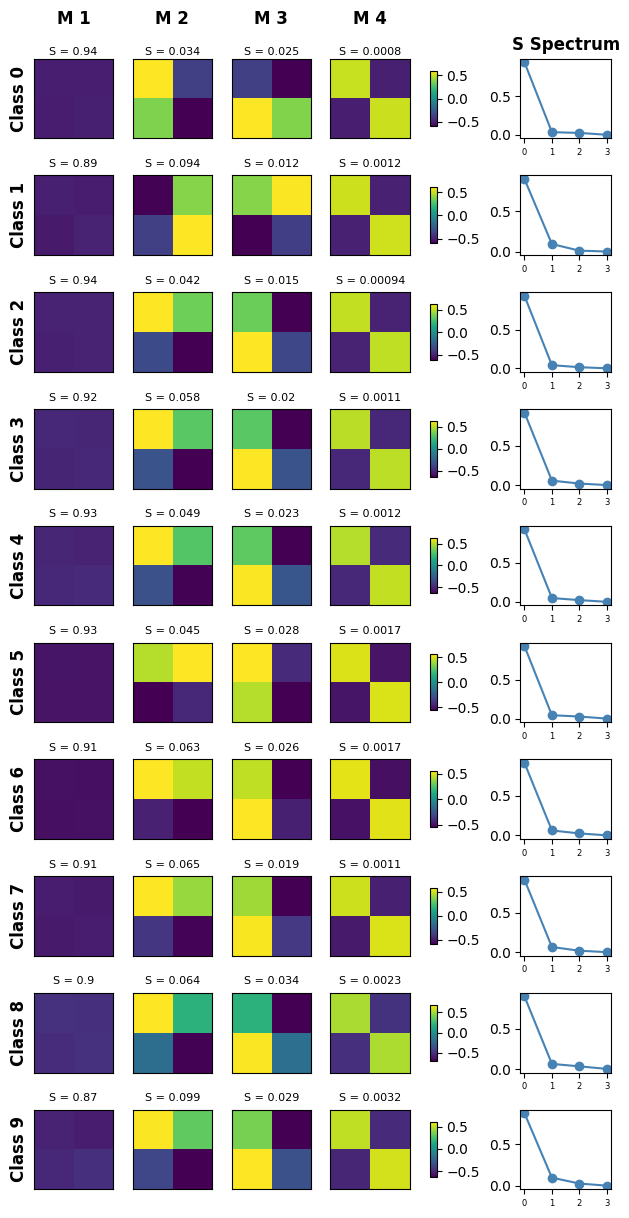

In [22]:
best_n_motif = 4

fig, best_2x2motif_array = plot_top_motifs(
    mpo_tensor_list, sweep_depth=4, top_k=best_n_motif
)
fig.savefig("plots/top_motifs_per_class_depth4.png", dpi=600, bbox_inches="tight")
plt.show()

Best motif array shape: (10, 3, 4, 4)
Singular values: [6.61119843e-01 1.75847145e-01 7.56391598e-02 4.72600181e-02
 2.61495875e-02 6.49180931e-03 3.26952936e-03 3.04116633e-03
 7.32808407e-04 1.95343453e-04 1.29822693e-04 6.13117225e-05
 2.73109282e-05 1.59672536e-05 1.50612274e-05 4.11503418e-06]


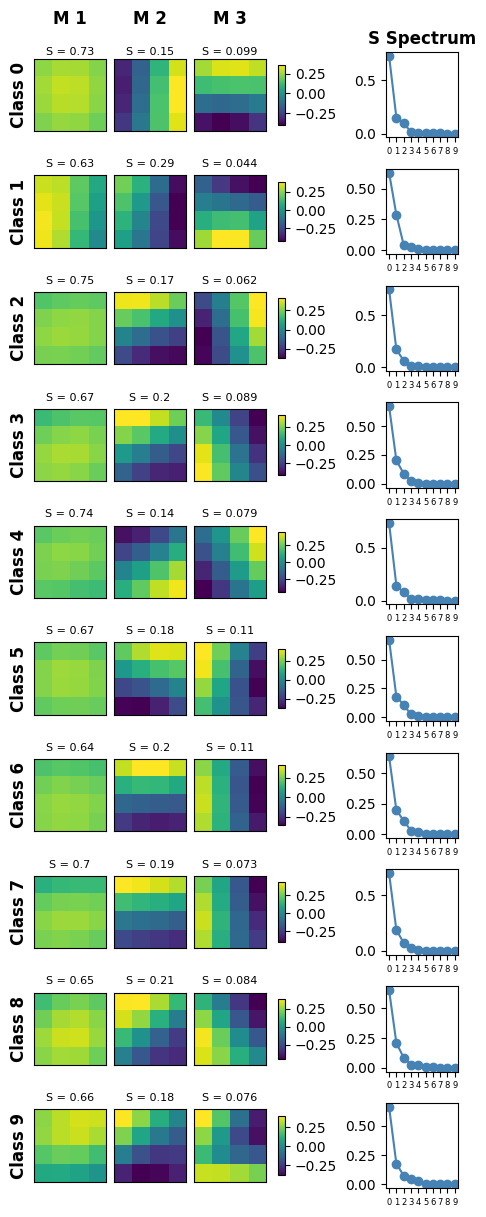

In [23]:
best_n_motif = 3

fig, best_4x4motif_array = plot_top_motifs(
    mpo_tensor_list, sweep_depth=3, top_k=best_n_motif
)
fig.savefig("plots/top_motifs_per_class_depth3.png", dpi=600, bbox_inches="tight")
plt.show()

In [24]:
best_4x4motif_array[0][0]

array([[0.23480781, 0.26380266, 0.26075618, 0.220606  ],
       [0.25621799, 0.29154189, 0.28635203, 0.23541266],
       [0.24828249, 0.28207568, 0.27721791, 0.22702056],
       [0.21639742, 0.243421  , 0.23764592, 0.19594775]])

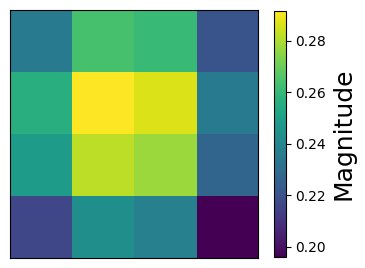

In [25]:
# motif for class 0, motif1, for report
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
im = ax.imshow(best_4x4motif_array[0][0].reshape(4, 4), cmap="viridis")

ax.set_xticks([])
ax.set_yticks([])

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Magnitude", fontsize=18)

plt.savefig("plots/motif0_class0.png", dpi=600, bbox_inches="tight")
plt.show()

In [26]:
# motif 3 from class 2 and 3

best_4x4motif_array = np.array(best_4x4motif_array)
class_2_motif3 = best_4x4motif_array[2, 2].reshape(-1)
class_3_motif3 = best_4x4motif_array[3, 2].reshape(-1)

print("class 2 motif 3:", class_2_motif3)
print("class 3 motif 3:", class_3_motif3)

class 2 motif 3: [-0.19539236 -0.03540158  0.20205994  0.40588052 -0.29840908 -0.09138858
  0.1789892   0.39558728 -0.37233313 -0.16880635  0.09160832  0.29789392
 -0.36093357 -0.19500279  0.02071365  0.18996435]
class 3 motif 3: [ 0.14597989 -0.01428924 -0.23780041 -0.40596214  0.26368515  0.07369767
 -0.17958843 -0.36867348  0.3769857   0.16986334 -0.09374407 -0.28626858
  0.40513656  0.21229376 -0.03136714 -0.20518397]


In [27]:
v2 = best_4x4motif_array[2, 2, :]
v3 = best_4x4motif_array[3, 2, :]

v2_flat = v2.ravel()
v3_flat = v3.ravel()

raw_dot = float(
    np.dot(v2_flat, v3_flat) / (np.linalg.norm(v2_flat) * np.linalg.norm(v3_flat))
)
print(f"Raw cosine: {raw_dot:.4f}")
print(f"Abs cosine: {abs(raw_dot):.4f}")


Raw cosine: -0.9944
Abs cosine: 0.9944


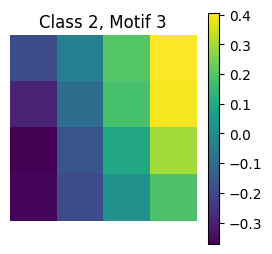

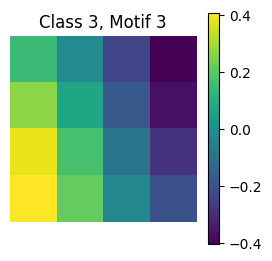

In [28]:
plt.figure(figsize=(3, 3))
plt.imshow(class_2_motif3.reshape(4, 4), cmap="viridis")
plt.colorbar()
plt.title("Class 2, Motif 3")
plt.axis("off")
plt.show()


plt.figure(figsize=(3, 3))
plt.imshow(class_3_motif3.reshape(4, 4), cmap="viridis")
plt.colorbar()
plt.title("Class 3, Motif 3")
plt.axis("off")
plt.show()

Best motif array shape: (10, 4, 8, 8)
Singular values: [4.79599639e-01 2.45958341e-01 1.09164700e-01 7.45804252e-02
 3.93472971e-02 2.45690498e-02 1.03650144e-02 6.59896560e-03
 3.92306292e-03 2.87503856e-03 1.86064057e-03 6.31637999e-04
 3.67637305e-04 7.57519172e-05 6.38392144e-05 1.89595018e-05
 3.82173888e-17 3.82173888e-17 3.82173888e-17 3.82173888e-17
 3.82173888e-17 3.82173888e-17 3.82173888e-17 3.82173888e-17
 3.82173888e-17 3.82173888e-17 3.82173888e-17 3.82173888e-17
 3.82173888e-17 3.82173888e-17 3.82173888e-17 3.82173888e-17
 3.82173888e-17 3.82173888e-17 3.82173888e-17 3.82173888e-17
 3.82173888e-17 3.82173888e-17 3.82173888e-17 3.82173888e-17
 3.82173888e-17 3.82173888e-17 3.82173888e-17 3.82173888e-17
 3.82173888e-17 3.82173888e-17 3.82173888e-17 3.82173888e-17
 3.82173888e-17 3.82173888e-17 3.82173888e-17 3.82173888e-17
 3.82173888e-17 3.82173888e-17 3.82173888e-17 3.82173888e-17
 3.82173888e-17 3.82173888e-17 3.82173888e-17 3.82173888e-17
 3.82173888e-17 3.82173888e-17

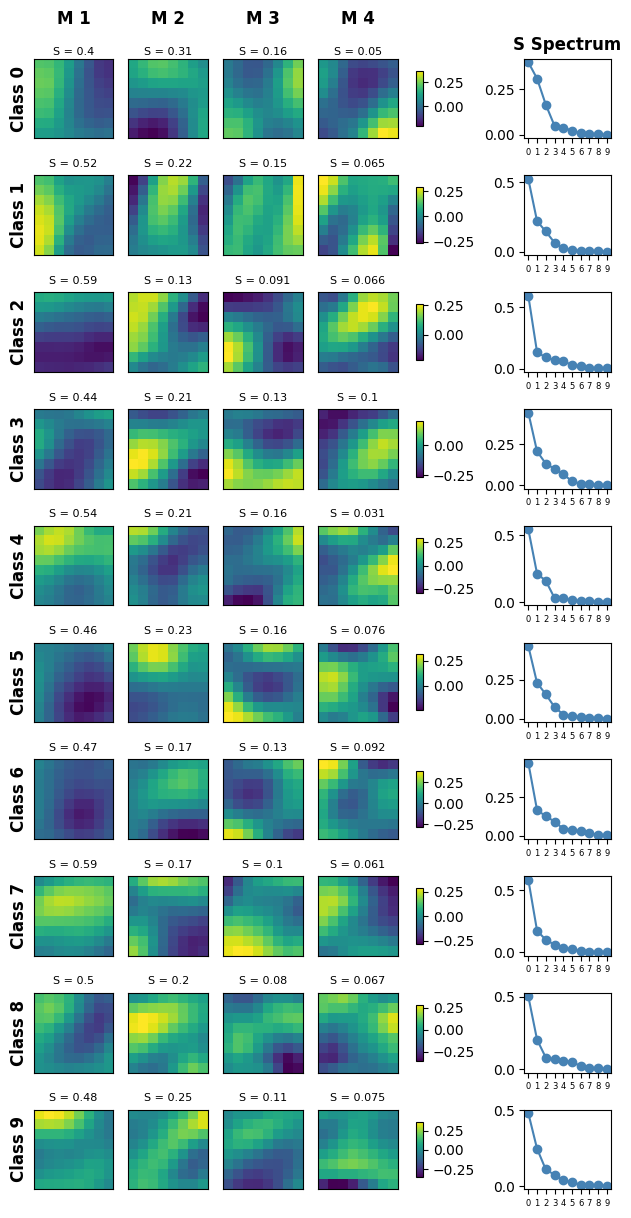

In [29]:
fig, best_8x8motif_array = plot_top_motifs(mpo_tensor_list, sweep_depth=2, top_k=4)
fig.savefig("plots/top_motifs_per_class_depth2.png", dpi=600, bbox_inches="tight")
plt.show()

Best motif array shape: (10, 5, 16, 16)
Singular values: [4.79430559e-01 2.48618146e-01 1.55842573e-01 1.16108722e-01
 2.53329324e-16 2.11361035e-16 1.90738082e-16 1.77458598e-16
 1.68275087e-16 1.66478434e-16 1.59891111e-16 1.32947335e-16
 1.28034523e-16 1.23239129e-16 1.20475092e-16 1.02624705e-16
 1.01615095e-16 9.59457375e-17 9.18758118e-17 8.75521862e-17
 8.00964501e-17 7.46240807e-17 6.82741628e-17 6.27977363e-17
 5.72388496e-17 4.95813812e-17 4.55465899e-17 4.55465899e-17
 4.55465899e-17 4.55465899e-17 4.55465899e-17 4.55465899e-17
 4.55465899e-17 4.55465899e-17 4.55465899e-17 4.55465899e-17
 4.55465899e-17 4.55465899e-17 4.55465899e-17 4.55465899e-17
 4.55465899e-17 4.55465899e-17 4.55465899e-17 4.55465899e-17
 4.55465899e-17 4.55465899e-17 4.55465899e-17 4.55465899e-17
 4.55465899e-17 4.55465899e-17 4.55465899e-17 4.55465899e-17
 4.55465899e-17 4.55465899e-17 4.55465899e-17 4.55465899e-17
 4.55465899e-17 4.55465899e-17 4.55465899e-17 4.55465899e-17
 4.55465899e-17 4.55465899e-

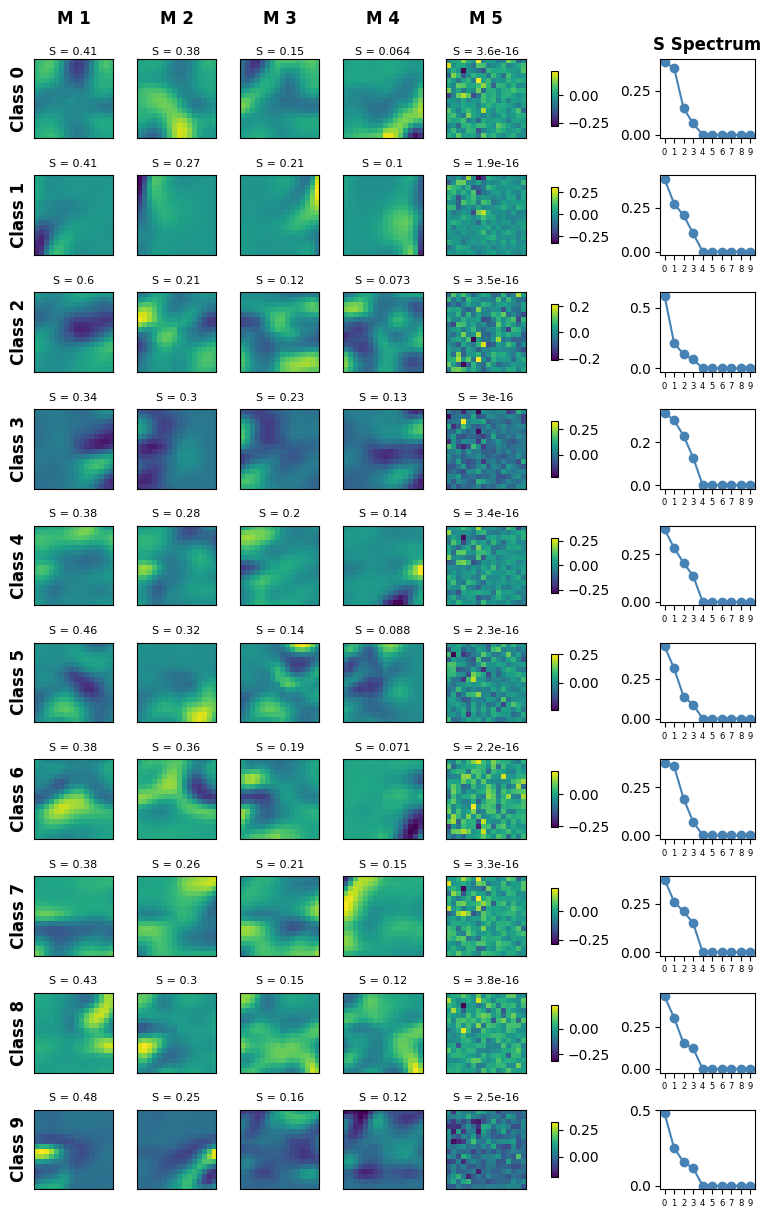

In [30]:
fig, best_16x16motif_array = plot_top_motifs(mpo_tensor_list, sweep_depth=1, top_k=5)
# fig.savefig("plots/top_motifs_per_class_depth1.png", dpi=600, bbox_inches="tight")
plt.show()

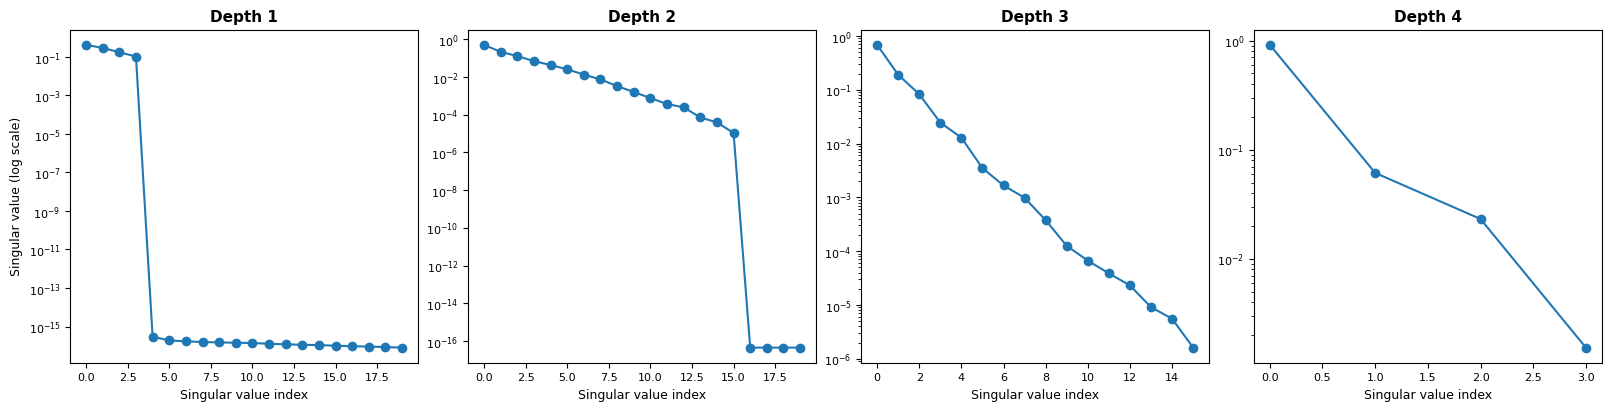

In [31]:
depths = [1, 2, 3, 4]
n_classes = 10
max_sv = 20

fig, axes = plt.subplots(
    1, len(depths), figsize=(len(depths) * 4, 4), constrained_layout=True
)

for col, depth in enumerate(depths):
    all_weights = []
    for class_idx in range(n_classes):
        t0 = mpo_tensor_list[0][class_idx].reshape(1, 4, -1)
        mpo_class = [t0] + list(mpo_tensor_list[1:])
        _, weights, _ = left_to_right_sweep(mpo_class, depth=depth)
        all_weights.append(weights[:max_sv])

    avg_weights = np.mean(all_weights, axis=0)

    ax = axes[col]
    ax.plot(range(len(avg_weights)), avg_weights, "o-")
    ax.set_yscale("log")
    ax.set_title(f"Depth {depth}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Singular value index", fontsize=9)
    if col == 0:
        ax.set_ylabel("Singular value (log scale)", fontsize=9)
    ax.tick_params(labelsize=8)

plt.savefig("plots/singular_values_avg_per_depth.png", dpi=300, bbox_inches="tight")
plt.show()

# Motif Overlap
Compute overlap between ith motifs from each class:  <br>
$$\langle \text{motif}_i^c \mid \text{motif}_j^{c'} \rangle$$
where $c$ and $c'$ are different classes

In [32]:
print(
    f"shape of array containing {best_n_motif} motifs that contribute the most for each class for each class",
    np.shape(best_4x4motif_array),
)


# flatten the motifs and convert to array
best_4x4motif_array = np.array(best_4x4motif_array)
best_4x4motif_array = best_4x4motif_array.reshape(10, best_n_motif, -1)


shape of array containing 3 motifs that contribute the most for each class for each class (10, 3, 4, 4)


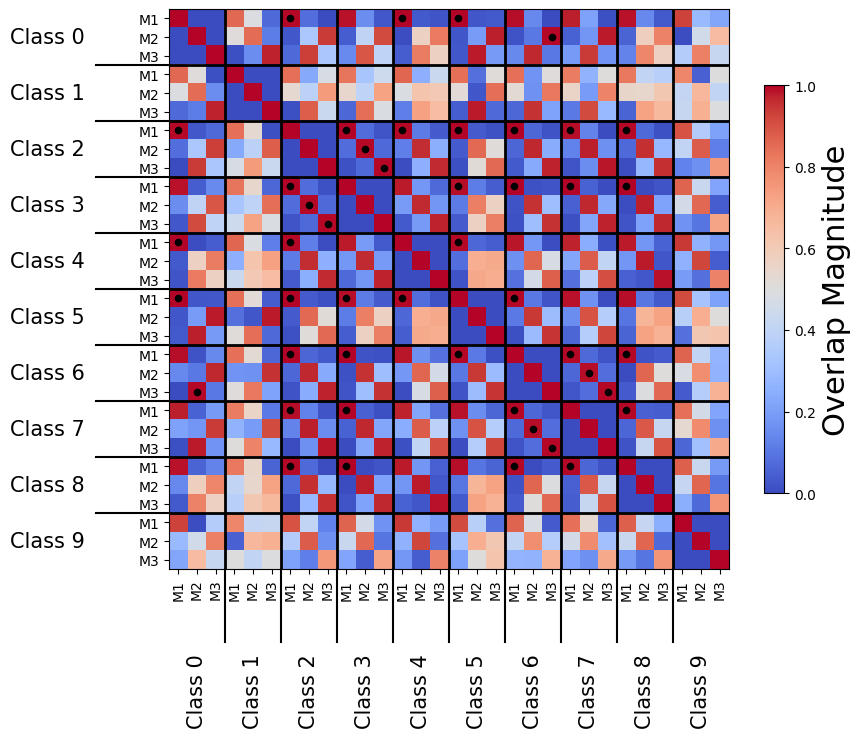

In [ ]:
def plot_motif_overlaps(best_motif_array, threshold=0.9):
    """compute and plot the overlap heatmap.
    Args:
        best_motif_array: shape (classes, motifs, vec_dim).
        threshold: minimum overlap value to mark cells with a black dot

    Returns:
        fig: figure object containing the heatmap

    """
    n_classes, n_motifs_per_class, vec_dim = best_motif_array.shape
    total_motifs = n_classes * n_motifs_per_class

    # flatten first two dims
    flat_motifs = best_motif_array.reshape(total_motifs, vec_dim)

    # normalise the vectors
    norms = np.linalg.norm(flat_motifs, axis=1, keepdims=True)
    flat_motifs_normalized = flat_motifs / norms

    # compute all-to-all overlap matrix
    overlap_matrix = np.dot(flat_motifs_normalized, flat_motifs_normalized.T)
    overlap_matrix = np.abs(overlap_matrix)

    color_center = 0.5
    div_norm = TwoSlopeNorm(vmin=0.0, vcenter=color_center, vmax=1.0)

    fig, ax = plt.subplots(figsize=(10, 10))
    im = ax.imshow(overlap_matrix, cmap="coolwarm", origin="upper", norm=div_norm)
    cbar = fig.colorbar(im, ax=ax, shrink=0.6, aspect=20)
    cbar.set_label("Overlap Magnitude", fontsize=22)

    # black dots on cells above threshold (skip diagonal)
    dot_rows, dot_cols = np.where(
        (overlap_matrix > threshold) & ~np.eye(total_motifs, dtype=bool)
    )
    ax.scatter(dot_cols, dot_rows, s=20, c="black", zorder=5)

    motif_positions = np.arange(total_motifs)
    motif_labels = [f"M{(i % n_motifs_per_class) + 1}" for i in range(total_motifs)]
    fontsize_tmp = 10
    ax.set_xticks(motif_positions)
    ax.set_xticklabels(motif_labels, fontsize=fontsize_tmp, rotation=90)
    ax.set_yticks(motif_positions)
    ax.set_yticklabels(motif_labels, fontsize=fontsize_tmp)

    # class label annotations
    centers = np.arange(n_motifs_per_class / 2 - 0.5, total_motifs, n_motifs_per_class)
    for i, c in enumerate(centers):
        ax.text(
            c,
            -0.15,
            f"Class {i}",
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=fontsize_tmp + 5,
            rotation=90,
            clip_on=False,
        )
        ax.text(
            -0.15,
            c,
            f"Class {i}",
            transform=ax.get_yaxis_transform(),
            ha="right",
            va="center",
            fontsize=fontsize_tmp + 5,
            clip_on=False,
        )

    # boundary lines between class
    boundaries = np.arange(
        n_motifs_per_class - 0.5, total_motifs - 0.5, n_motifs_per_class
    )
    for b in boundaries:
        ax.axhline(b, color="black", linewidth=2, alpha=1)
        ax.axvline(b, color="black", linewidth=2, alpha=1)
        ax.plot(
            [b, b],
            [0, -0.13],
            transform=ax.get_xaxis_transform(),
            color="black",
            linewidth=1.5,
            clip_on=False,
        )
        ax.plot(
            [0, -0.13],
            [b, b],
            transform=ax.get_yaxis_transform(),
            color="black",
            linewidth=1.5,
            clip_on=False,
        )

    # ax.set_title(
    #     f"Overlap Matrix Between All Class Motifs \n Color Thresholded at {color_center} "
    # )
    fig.subplots_adjust(left=0.2, bottom=0.2)
    return fig


fig = plot_motif_overlaps(np.array(best_4x4motif_array), threshold=0.99)
plt.savefig("plots/overlap_heatmap_motif4x4.png", dpi=600, bbox_inches="tight")


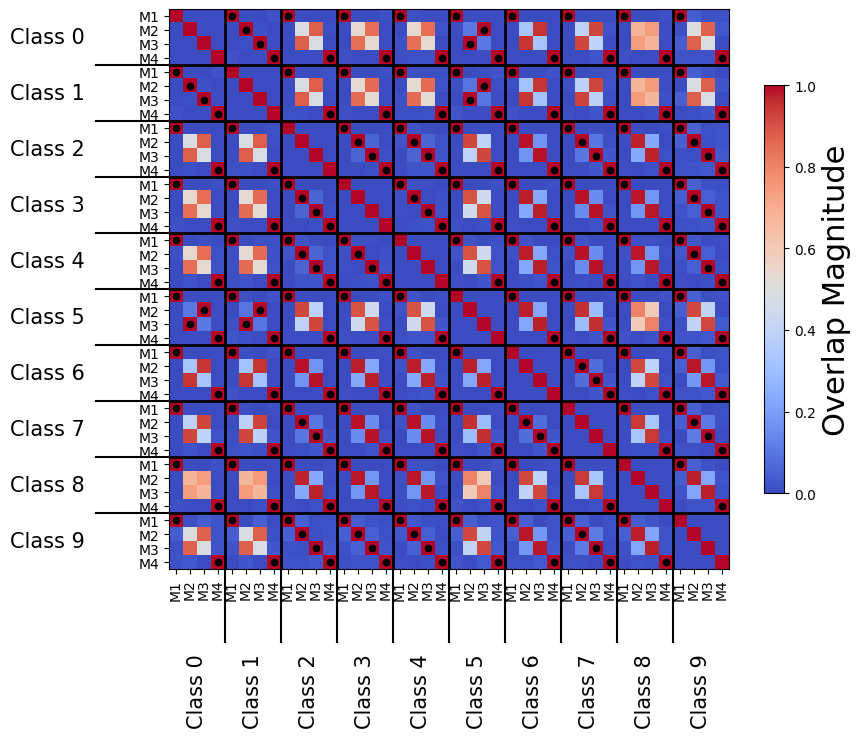

In [34]:
# overlap between 2x2 masks

best_2x2motif_array = np.array(best_2x2motif_array)
best_2x2motif_array = best_2x2motif_array.reshape(10, 4, -1)

fig = plot_motif_overlaps(best_2x2motif_array, threshold=0.99)
plt.savefig("plots/overlap_heatmap_motif2x2.png", dpi=600)

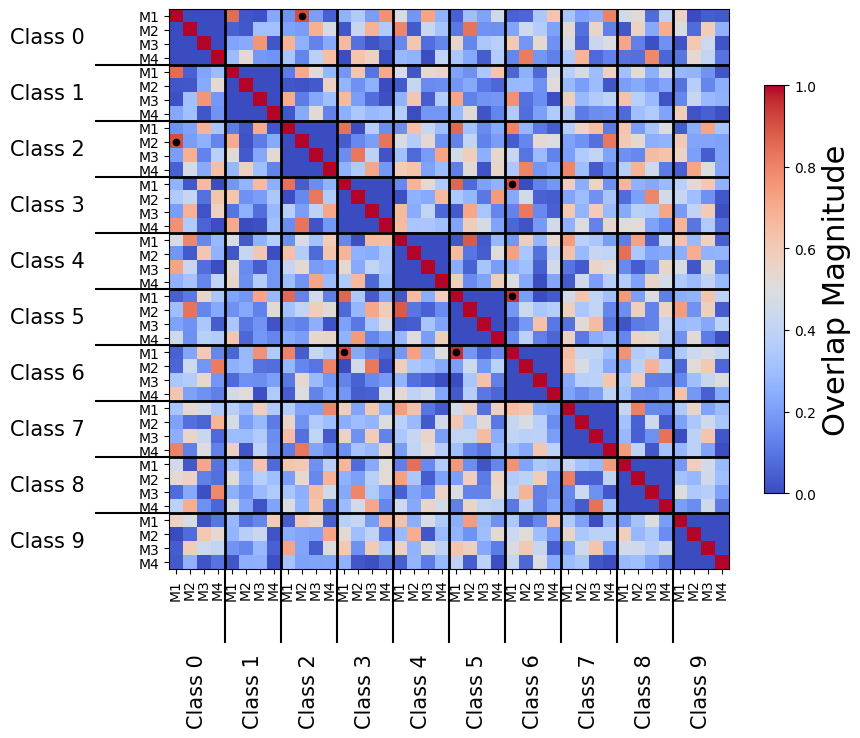

In [35]:
# overlap between best 8x8 motifs

best_8x8motif_array = np.array(best_8x8motif_array)
best_8x8motif_array = best_8x8motif_array.reshape(10, best_n_motif + 1, -1)

fig = plot_motif_overlaps(best_8x8motif_array)
plt.savefig("plots/overlap_heatmap_motif8x8.png", dpi=600, bbox_inches="tight")

In [36]:
raise SystemExit("Stopping execution here")

SystemExit: Stopping execution here

C:\Users\alios\AppData\Roaming\Python\Python312\site-packages\IPython\core\interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


# MPO motifs modifications
Motif 1 and 2 for class 2, 3, 7 have a strong correlation. <br>

- from Deterministic Tensor Network Classifiers paper we know that the highest accuracy for mpo is achieved for $D_{final}$ $\approx$ 20. So to speed up the analysis process use mpo with $D_{final}$ = 30.
 

In [37]:
n_classes = 10
bond_dims_to_eval = [10, 20, 30, 40]
baseline_stats_dict = {}

# code to compute and save accuracies of different models for different bond dimensions

# for bond_dim_val in bond_dims_to_eval:
#     file_path = (
#         f"mnist_tensors_{bond_dim_val}_{n_classes}_classes_zweight_10_qubits.npz"
#     )
#     data = np.load(file_path, allow_pickle=True)

#     mpo_tensor_list_truncated = data["classifier_mpo"]
#     print(f"\n---------- Bond dim {bond_dim_val}")
#     print(f"shape mpo: {mpo_tensor_list_truncated.shape}")
#     for i, M_site in enumerate(mpo_tensor_list_truncated):
#         print(f"Site {i}, shape: {M_site.shape}")

#     # evaluate accuracy
#     accuracies_each_class_original, final_accuracy_original_mpo = evaluate_accuracy(
#         mpo_tensor_list_truncated, cluster_list_test, ensemble_mode=False
#     )
#     baseline_stats = (accuracies_each_class_original, final_accuracy_original_mpo)
#     print(baseline_stats)

#     # save per bond dim
#     save_path = f"mpo_baseline_stats_dim_{bond_dim_val}.npz"
#     np.savez(
#         save_path,
#         per_class_accs=baseline_stats[0],
#         overall_acc=[baseline_stats[1]],
#     )

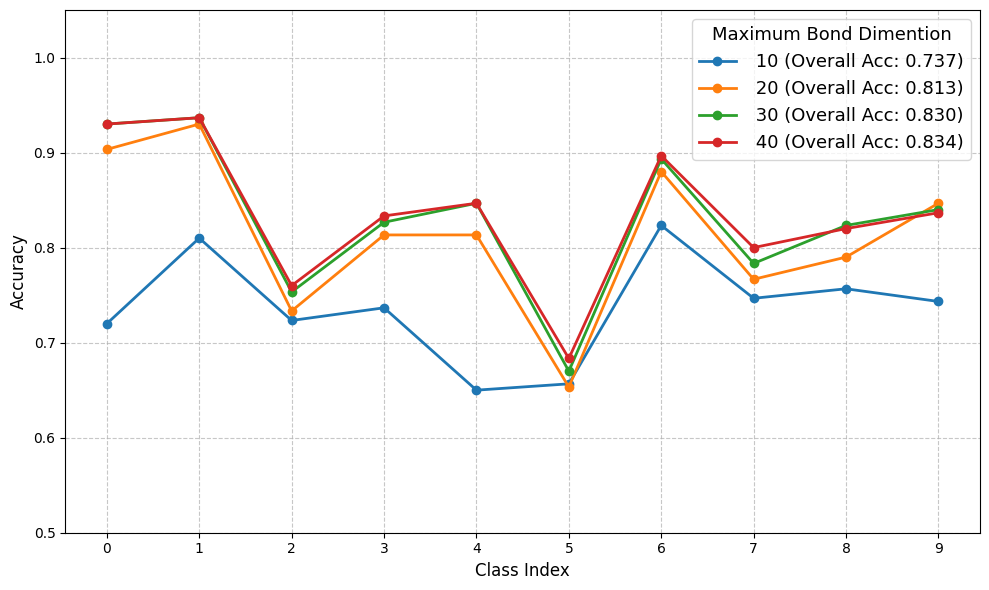

In [38]:
plt.figure(figsize=(10, 6))
class_indices = np.arange(n_classes)
for bond_dim_val in bond_dims_to_eval:
    save_path = f"mpo_baseline_stats_dim_{bond_dim_val}.npz"
    data = np.load(save_path)

    per_class_accs = data["per_class_accs"]
    overall_acc = data["overall_acc"][0]

    plt.plot(
        class_indices,
        per_class_accs,
        marker="o",
        linestyle="-",
        linewidth=2,
        markersize=6,
        label=f" {bond_dim_val} (Overall Acc: {overall_acc:.3f})",
    )

# plt.title("Per-Class Accuracy for Different Bond Dimensions", fontsize=14)
plt.xlabel("Class Index", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(class_indices)
plt.ylim(0.5, 1.05)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(title="Maximum Bond Dimention", title_fontsize=13, fontsize=13, frameon=True)
plt.tight_layout()

plt.savefig("plots/mpo_accuracy_comparison.png", dpi=300)
plt.show()

no particular difference between max. bond dimension 20, 30 and 40. Hence use bond dimension 20 from now on 

In [39]:
# load baseline stats for bond dim 20
bond_dim_val = 20
data = np.load(f"mpo_baseline_stats_dim_{bond_dim_val}.npz")
baseline_stats = (data["per_class_accs"], float(data["overall_acc"]))

file_path = f"mnist_tensors_{bond_dim_val}_{n_classes}_classes_zweight_10_qubits.npz"
data_mpo = np.load(file_path, allow_pickle=True)

mpo_tensor_list_truncated = data_mpo["classifier_mpo"]

C:\Users\alios\AppData\Local\Temp\ipykernel_30148\2990523354.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  baseline_stats = (data["per_class_accs"], float(data["overall_acc"]))


Evaluating ensemble with truncate_n=1
Evaluating ensemble with truncate_n=2
Evaluating ensemble with truncate_n=3
Evaluating ensemble with truncate_n=4


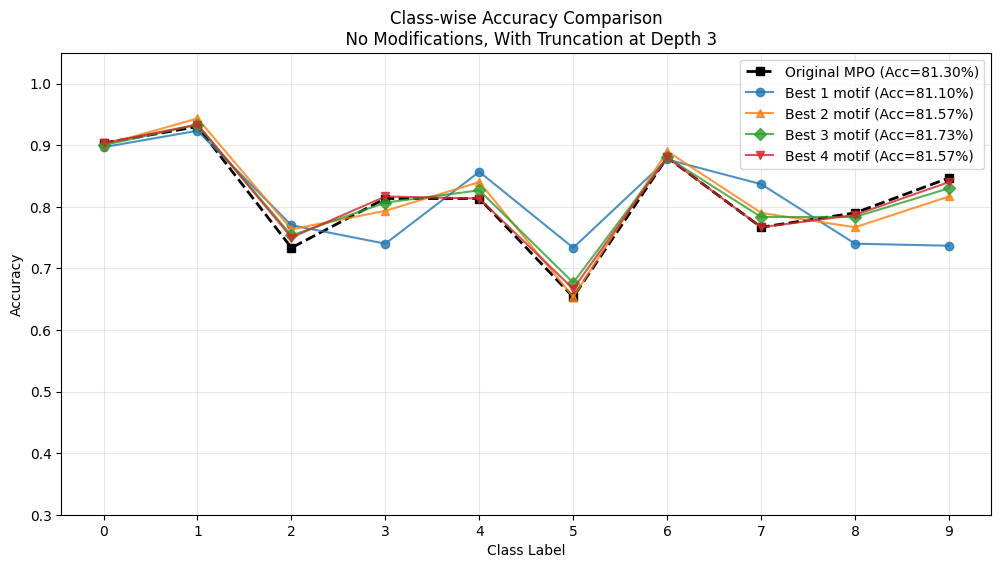

In [40]:
mods_no_change = {}

no_mod_n_truncation = [1, 2, 3, 4]

fig, results_dict_no_mod, _ = plot_ensemble_performance(
    mpo_tensor_list_truncated,
    mods_no_change,
    cluster_list_test,
    baseline_stats=baseline_stats,
    sweep_depth=3,
    truncate_n=no_mod_n_truncation,
    title_str=" No Modifications, With Truncation at Depth 3",
)
plt.savefig("plots/ensemble_no_modifications.png", dpi=300)

Evaluating ensemble with truncate_n=1
Evaluating ensemble with truncate_n=2
Evaluating ensemble with truncate_n=3
Evaluating ensemble with truncate_n=4


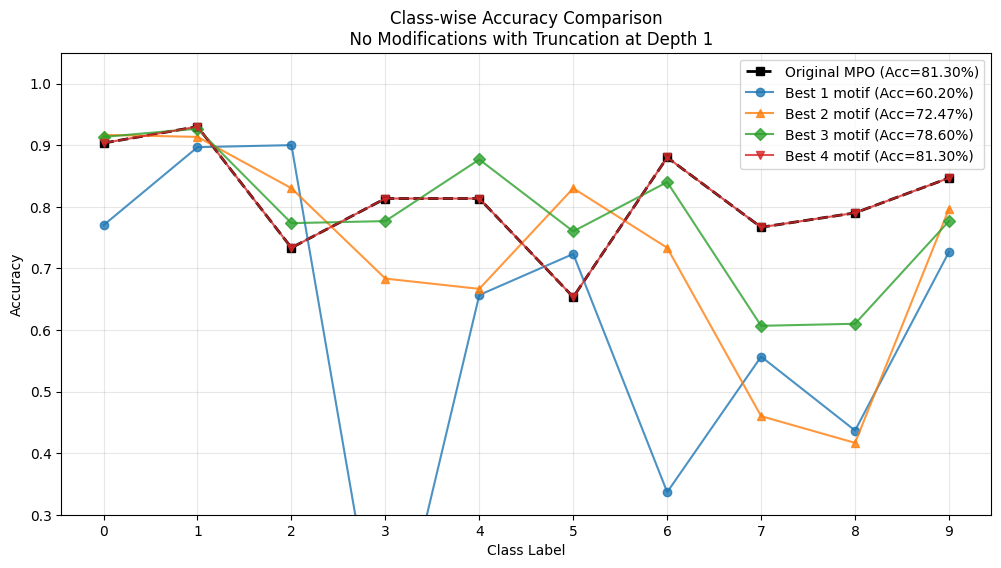

In [41]:
truncate_n = [1, 2, 3, 4]

# perform truncation at site 1, and compare original and truncated mpo
fig = plot_ensemble_performance(
    mpo_tensor_list_truncated,
    mods_no_change,
    cluster_list_test=cluster_list_test,
    baseline_stats=baseline_stats,
    truncate_n=truncate_n,
    sweep_depth=1,
    title_str=" No Modifications with Truncation at Depth 1",
)

plt.savefig("plots/accuracy_ensemble_with_truncation_no_mods_depth1.png", dpi=300)

- Interestingly some classes are not highly affected by the harsh compression between site 1 and site 2. 
- Accuracy is not affected if bond dimension 20 is compressed down to 4. 

Evaluating ensemble with truncate_n=2
Evaluating ensemble with truncate_n=3
Evaluating ensemble with truncate_n=4


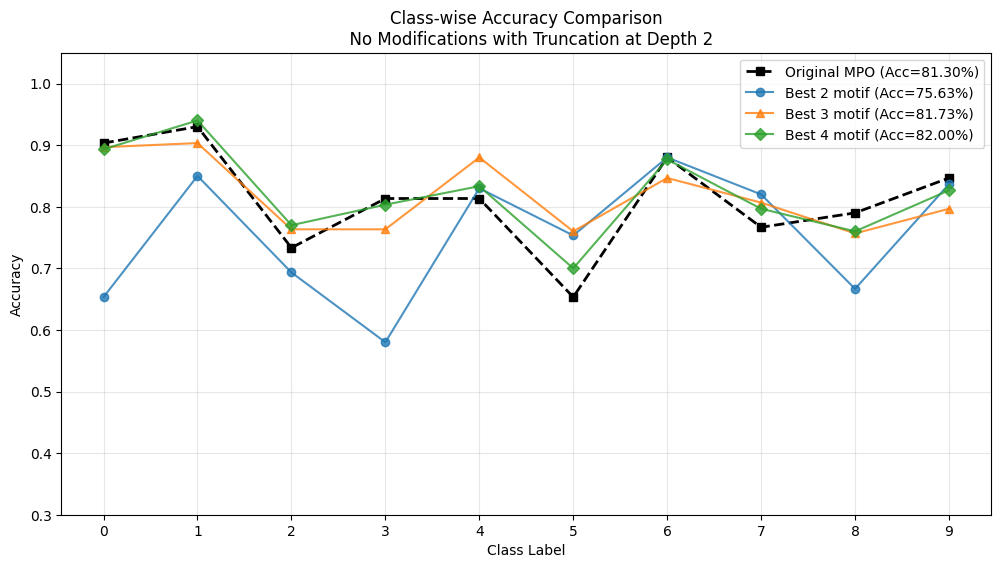

In [42]:
truncate_n_depth2 = [2, 3, 4]

# perform truncation at site 1, and compare original and truncated mpo
fig = plot_ensemble_performance(
    mpo_tensor_list_truncated,
    mods={},
    cluster_list_test=cluster_list_test,
    baseline_stats=baseline_stats,
    truncate_n=truncate_n_depth2,
    sweep_depth=2,
    title_str=" No Modifications with Truncation at Depth 2",
)

plt.savefig("plots/accuracy_ensemble_with_truncation_no_mods_depth2.png", dpi=300)


Next step 
- How far can we push these modifications, without a drastic change in accuracy 


- Truncate at each step by using brute force grid search of possible configuration for bond truncation

In [43]:
# construct raw (right-canonical) mps chains for all 10 classes
raw_mps_ensemble = []
for c in range(10):
    t0 = mpo_tensor_list_truncated[0][c].reshape(1, 4, -1)
    raw_chain = [t0] + [t.copy() for t in mpo_tensor_list_truncated[1:]]
    raw_mps_ensemble.append(raw_chain)


def evaluate_config(config, raw_ensemble, test_data):
    """evaluate accuracy for a given bond dimension config. returns (config, overall_acc)."""
    truncated_ens = [
        truncate_mpo_via_gauge(mps, list(config))[0] for mps in raw_ensemble
    ]
    _, overall_acc = evaluate_accuracy(truncated_ens, test_data, ensemble_mode=True)
    return config, overall_acc


# search space
bond_vals = range(1, 6)
configs = list(itertools.product(bond_vals, repeat=4))

print(f"Evaluating {len(configs)} configurations")

results = Parallel(n_jobs=-1)(
    delayed(evaluate_config)(cfg, raw_mps_ensemble, cluster_list_test)
    for cfg in configs
)

Evaluating 625 configurations


In [44]:
# filter only configs within baseline accuracy
threshold = baseline_stats[1] - 0.005
good_configs = [(cfg, acc) for cfg, acc in results if acc >= threshold]

# sort by number of parameters (sum of tensor sizes) ascending
good_configs.sort(key=lambda x: count_params(x[0]))

# top 10 lowest parameter configs
print(f"{'Config':<20} {'Acc':>8} {'n-params':>10}")
print("-" * 40)
for cfg, acc in good_configs[:10]:
    n = count_params(cfg)
    print(f"{str(cfg):<20} {acc:>8.2%} {n:>10}")


Config                    Acc   n-params
----------------------------------------
(4, 3, 2, 1)           81.40%         25
(4, 4, 1, 1)           80.90%         26
(4, 3, 2, 2)           81.33%         28
(4, 4, 1, 2)           80.83%         28
(4, 3, 3, 1)           82.07%         29
(5, 3, 2, 1)           81.40%         29
(4, 4, 1, 3)           80.80%         30
(4, 3, 2, 3)           81.33%         31
(4, 4, 2, 1)           82.23%         31
(4, 5, 1, 1)           81.33%         31


In [45]:
# accuracy of config 4,3,1,1
match = [(cfg, acc) for cfg, acc in results if cfg == (4, 3, 1, 1)]
print(match)


[((4, 3, 1, 1), 0.8033333333333333)]


In [46]:
choosen_config = good_configs[1][0]
# modify mpo ensemble with choosen config
# lets set class 0 motif 1 (4x4 motif, hence depth 3) to be equal motif for all the other classes
class_source = 0  # class to source motifs from

mods1 = {
    # {target_class: [(source_class, source_motif_idx, target_motif_idx), ...]}
    0: [(class_source, 0, 0)],
    1: [(class_source, 0, 0)],
    2: [(class_source, 0, 0)],
    3: [(class_source, 0, 0)],
    4: [(class_source, 0, 0)],
    5: [(class_source, 0, 0)],
    6: [(class_source, 0, 0)],
    7: [(class_source, 0, 0)],
    8: [(class_source, 0, 0)],
    9: [(class_source, 0, 0)],
}

In [47]:
mods2 = {c: 0 for c in range(1, 10)}


Evaluating ensemble with truncate_n=1
Site 0, shape: (1, 4, 4)
Site 1, shape: (4, 4, 4)
Site 2, shape: (4, 4, 1)
Site 3, shape: (1, 4, 1)
Site 4, shape: (1, 4, 1)


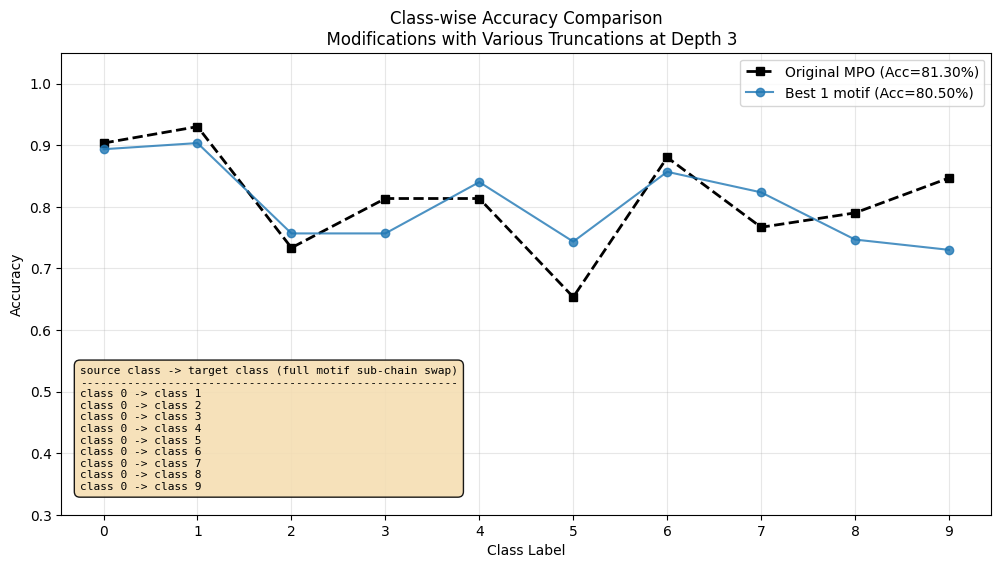

In [48]:
list_truncate_n = [1]
# truncate prototypical mps and force motif 1 (4x4) to be identical across all classes


fig, results_dict_mod1, ensemble_mod1 = plot_ensemble_performance(
    mpo_tensor_list_truncated,
    mods2,
    cluster_list_test,
    baseline_stats=baseline_stats,
    truncate_n=list_truncate_n,
    sweep_depth=3,
    title_str=" Modifications with Various Truncations at Depth 3",
)
# plt.savefig("plots/accuracy_ensemble_with_various_truncations_mods1.png", dpi=300)


# ensemble_mod1 is a 10  MPS chains, truncate each one individually
truncated_ensemble_mod1 = [
    truncate_mpo_via_gauge(chain, list(choosen_config))[0] for chain in ensemble_mod1
]
# shape of the new configuration
for i, tensor in enumerate(truncated_ensemble_mod1[0]):
    print(f"Site {i}, shape: {tensor.shape}")

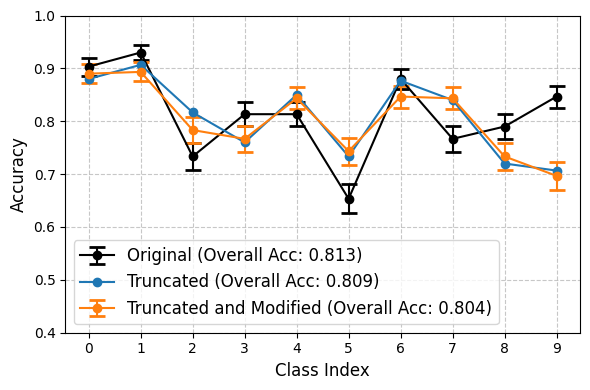

In [77]:
# plot of accuracy of teh new configuration
class_acc_mod1_truncated, class_acc_mod1_truncated_tot = evaluate_accuracy(
    truncated_ensemble_mod1, cluster_list_test, ensemble_mode=True
)

# truncate original mpo ensemble for fair comparison
class_acc_original_truncated, class_acc_original_truncated_tot = evaluate_accuracy(
    [
        truncate_mpo_via_gauge(chain, list(choosen_config))[0]
        for chain in raw_mps_ensemble
    ],
    cluster_list_test,
    ensemble_mode=True,
)

# standard errors: SE = sqrt(p*(1-p)/n) for each class
class_sizes = np.array([len(c) for c in cluster_list_test])

baseline_acc = np.array(baseline_stats[0])
se_baseline = np.sqrt(baseline_acc * (1 - baseline_acc) / class_sizes)

acc_orig_trunc = np.array(class_acc_original_truncated)
se_orig_trunc = np.sqrt(acc_orig_trunc * (1 - acc_orig_trunc) / class_sizes)

acc_mod1_trunc = np.array(class_acc_mod1_truncated)
se_mod1_trunc = np.sqrt(acc_mod1_trunc * (1 - acc_mod1_trunc) / class_sizes)

plt.figure(figsize=(6, 4))

plt.errorbar(
    class_indices,
    baseline_acc,
    yerr=se_baseline,
    color="black",
    marker="o",
    linestyle="-",
    linewidth=1.5,
    markersize=6,
    capsize=6,
    capthick=2,
    label=f"Original (Overall Acc: {baseline_stats[1]:.3f})",
)

plt.errorbar(
    class_indices,
    acc_orig_trunc,
    # yerr=se_orig_trunc,
    marker="o",
    linestyle="-",
    linewidth=1.5,
    markersize=6,
    capsize=6,
    capthick=2,
    label=f"Truncated (Overall Acc: {class_acc_original_truncated_tot:.3f})",
)

plt.errorbar(
    class_indices,
    acc_mod1_trunc,
    yerr=se_mod1_trunc,
    marker="o",
    linestyle="-",
    linewidth=1.5,
    markersize=6,
    capsize=6,
    capthick=2,
    label=f"Truncated and Modified (Overall Acc: {class_acc_mod1_truncated_tot:.3f})",
)

plt.xlabel("Class Index", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(class_indices)
plt.ylim(0.4, 1.0)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()

plt.savefig("plots/modified_ensemble_truncated.png", dpi=600, bbox_inches="tight")

In [63]:
se_mod1_trunc

array([0.0180647 , 0.01782217, 0.02378531, 0.02441918, 0.02098589,
       0.02521831, 0.02080242, 0.02098589, 0.02553139, 0.02654067])

In [61]:
se_orig_trunc

array([0.01876166, 0.01679506, 0.02233997, 0.02465766, 0.02061553,
       0.02553139, 0.0189844 , 0.02116601, 0.02592296, 0.02628617])

In [60]:
se_baseline

array([0.01706089, 0.01473092, 0.02553139, 0.02249609, 0.02249609,
       0.02747659, 0.01876166, 0.02441918, 0.02351595, 0.02080242])

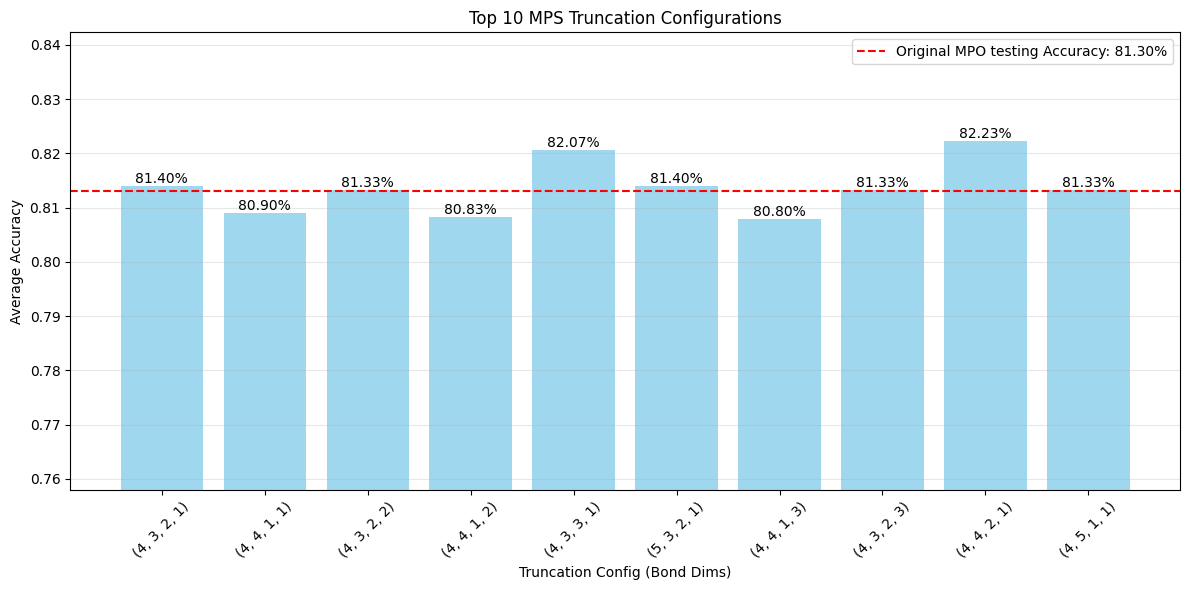

Best Config: ((4, 3, 2, 1), 0.814)


In [50]:
top_number = 10

top_x = good_configs[:top_number]

labels = [str(r[0]) for r in top_x]
accuracies = [r[1] for r in top_x]

fig = plt.figure(figsize=(12, 6))
bars = plt.bar(labels, accuracies, color="skyblue", alpha=0.8)


for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{height:.2%}",
        ha="center",
        va="bottom",
    )

plt.axhline(
    y=baseline_stats[1],
    color="r",
    linestyle="--",
    label=f"Original MPO testing Accuracy: {baseline_stats[1]:.2%}",
)
plt.xlabel("Truncation Config (Bond Dims)")
plt.ylabel("Average Accuracy")
plt.title(f"Top {top_number} MPS Truncation Configurations")
plt.ylim(min(accuracies) - 0.05, max(accuracies) + 0.02)
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.legend()


plt.savefig("plots/top_mps_truncation_configs.png", dpi=600, bbox_inches="tight")

plt.show()
print("Best Config:", top_x[0])

Class 0 shapes: [(1, 4, 4), (4, 4, 3), (3, 4, 2), (2, 4, 1), (1, 4, 1)]


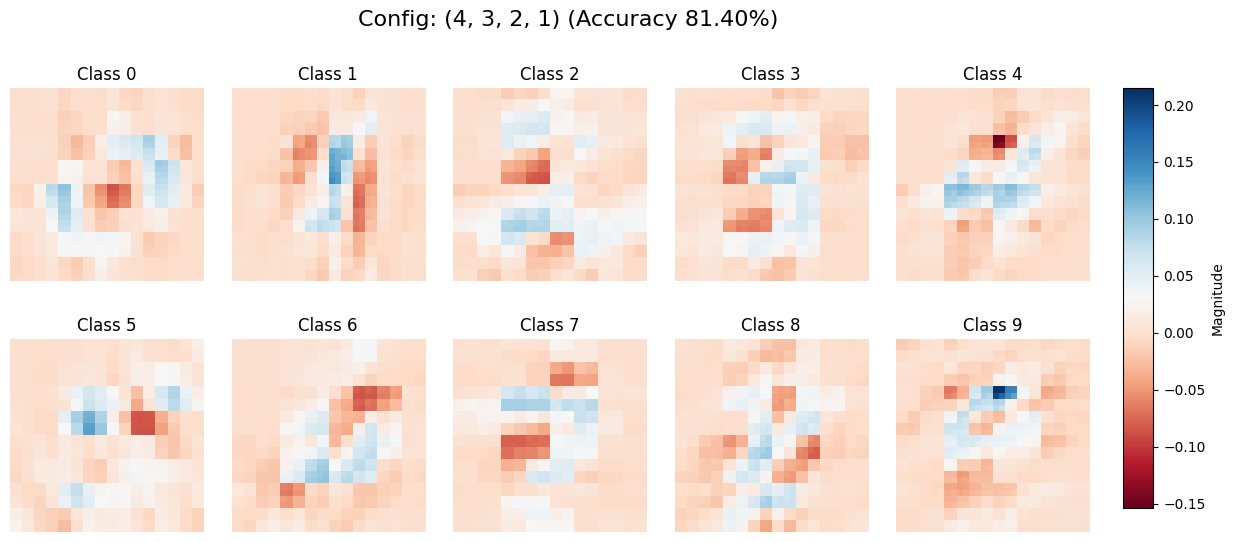

Class 0 shapes: [(1, 4, 4), (4, 4, 4), (4, 4, 1), (1, 4, 1), (1, 4, 1)]


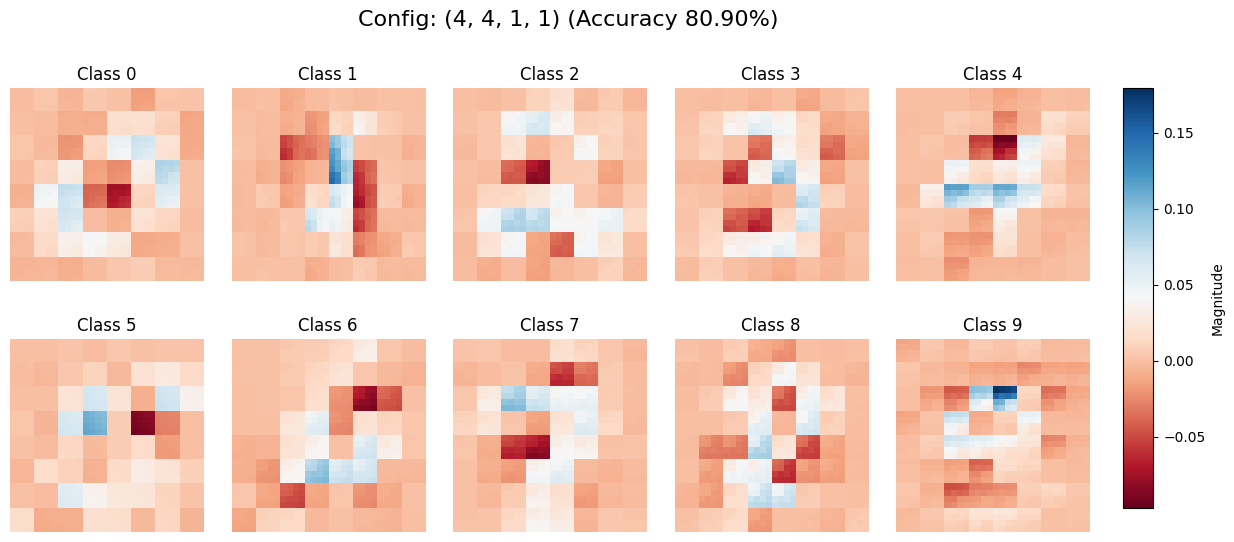

Class 0 shapes: [(1, 4, 4), (4, 4, 3), (3, 4, 2), (2, 4, 2), (2, 4, 1)]


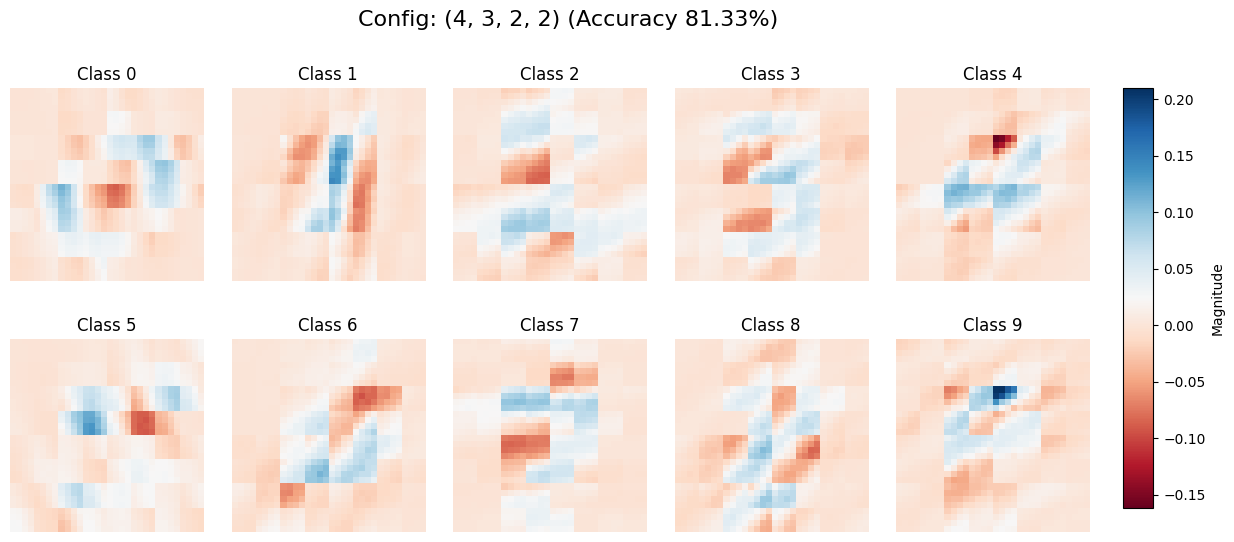

In [51]:
# plot of masks created by the 3 best configs
best_configs = [top_x[i][0] for i in range(3)]

for config_idx, config in enumerate(best_configs):
    truncated_ens = [
        truncate_mpo_via_gauge(mps, list(config))[0] for mps in raw_mps_ensemble
    ]

    print(f"Class 0 shapes: {[t.shape for t in truncated_ens[0]]}")

    class_projectors = []
    for class_idx in range(10):
        img = generalized_reconstruction(
            truncated_ens[class_idx], selection_index=0, transpose_result=True
        )
        class_projectors.append(img)

    v_min = np.min([np.min(im) for im in class_projectors])
    v_max = np.max([np.max(im) for im in class_projectors])

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle(
        f"Config: {config} (Accuracy {top_x[config_idx][1] * 100:.2f}%)", fontsize=16
    )

    for i, ax in enumerate(axes.flatten()):
        if i < len(class_projectors):
            im = ax.imshow(class_projectors[i], cmap="RdBu", vmin=v_min, vmax=v_max)
            ax.set_title(f"Class {i}")
        ax.axis("off")

    fig.subplots_adjust(right=0.85, top=0.85, wspace=0.1, hspace=0.3)

    cbar_ax = fig.add_axes([0.87, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label="Magnitude")

    plt.savefig(
        f"plots/class_projectors_best_config_{config_idx + 1}.png",
        dpi=300,
    )

    plt.show()

# Comparison between truncating MPS and truncating MPO


In [52]:
from my_functions import truncate_mpo_via_gauge, count_params, grid_search_mpo_config


# configuration search using grid search
# original bond dims are 20, 20, 16, 4

bounds = [(5, 18), (1, 10), (1, 2), (1, 1)]

size_search_space = np.prod([b[1] - b[0] + 1 for b in bounds])
print("search space:", size_search_space)


search space: 280


In [53]:
threshold = baseline_stats[1] - 0.005

best_conf_mpo, best_acc, all_results = grid_search_mpo_config(
    mpo_tensor_list_truncated,
    cluster_list_test,
    bounds=bounds,
    accuracy_threshold=threshold,
)
print(best_conf_mpo, best_acc)


(15, 4, 2, 1) 0.8096666666666666


Bond config: [4, 4, 1, 1]
  Class 0 â€” Site 0: (1, 4, 4)
  Class 0 â€” Site 1: (4, 4, 4)
  Class 0 â€” Site 2: (4, 4, 1)
  Class 0 â€” Site 3: (1, 4, 1)
  Class 0 â€” Site 4: (1, 4, 1)
Original MPO shapes:
  Site 0: (10, 4, 20)
  Site 1: (20, 4, 20)
  Site 2: (20, 4, 16)
  Site 3: (16, 4, 4)
  Site 4: (4, 4, 1)

Compressed MPO shapes:
  Site 0: (10, 4, 15)
  Site 1: (15, 4, 4)
  Site 2: (4, 4, 2)
  Site 3: (2, 4, 1)
  Site 4: (1, 4, 1)
Overall accuracy: 80.97%


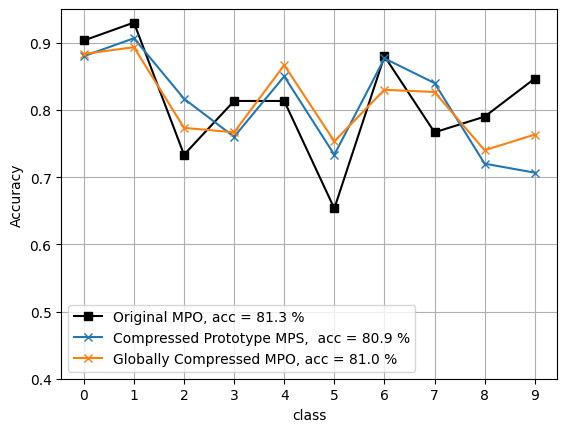

In [54]:
# bond configuration
bond_config_ens = [4, 4, 1, 1]

truncated_ensemble_gauge = []
all_singular_values = []

for c in range(10):
    # extract per-class MPS chain
    t0 = mpo_tensor_list_truncated[0][c].reshape(1, 4, -1)
    raw_chain = [t0] + [t.copy() for t in mpo_tensor_list_truncated[1:]]

    # truncate via SVD canonical gauge
    trunc_chain, svs = truncate_mpo_via_gauge(raw_chain, bond_config_ens)
    truncated_ensemble_gauge.append(trunc_chain)
    all_singular_values.append(svs)

print(f"Bond config: {bond_config_ens}")
for i, tensor in enumerate(truncated_ensemble_gauge[0]):
    print(f"  Class 0 â€” Site {i}: {tensor.shape}")

# evaluate accuracy
class_accs, overall_acc = evaluate_accuracy(
    truncated_ensemble_gauge, cluster_list_test, ensemble_mode=True
)


# Compress the full MPO directly
# bond_config_mpo = [18, 5, 2, 1]

# original shapes
print("Original MPO shapes:")
for i, t in enumerate(mpo_tensor_list_truncated):
    print(f"  Site {i}: {t.shape}")

compressed_mpo, _ = truncate_mpo_via_gauge(mpo_tensor_list_truncated, best_conf_mpo)

print("\nCompressed MPO shapes:")
for i, t in enumerate(compressed_mpo):
    print(f"  Site {i}: {t.shape}")

class_accs_global_truncation, overall_acc_global_truncation = evaluate_accuracy(
    compressed_mpo, cluster_list_test, ensemble_mode=False
)
print(f"Overall accuracy: {overall_acc_global_truncation:.2%}")


# plots
plt.plot(
    baseline_stats[0],
    "ks-",
    label=f"Original MPO, acc = {baseline_stats[1] * 100:.1f} %",
)
plt.plot(
    class_accs,
    "x-",
    label=f"Compressed Prototype MPS,  acc = {overall_acc * 100:.1f} %",
)


plt.plot(
    class_accs_global_truncation,
    "x-",
    label=f"Globally Compressed MPO, acc = {overall_acc_global_truncation * 100:.1f} %",
)

plt.xlabel("class")
plt.ylabel("Accuracy")
plt.xticks(range(10))
plt.ylim(0.4, 0.95)
plt.grid()
plt.legend()

In [55]:
print(f"Ensemble {bond_config_ens}:  {10 * count_params(bond_config_ens):,} params")
print(f"Full MPO {best_conf_mpo}:  {count_params(best_conf_mpo):,} params")
print(f"Ratio: {10 * count_params(bond_config_ens) / count_params(best_conf_mpo):.1f}")


Ensemble [4, 4, 1, 1]:  260 params
Full MPO (15, 4, 2, 1):  86 params
Ratio: 3.0


In [56]:
bond_dim_data = 8
n_qubits = 10

cluster_list_train = np.load(
    save_mnist_dir
    / f"mnist_cluster_list_bond_dim_{bond_dim_data}_{n_qubits}_qubits_train.npz",
    allow_pickle=True,
)["cluster_list"]

In [57]:
# size of training and testing sets
train_size = sum(len(cluster) for cluster in cluster_list_train)
test_size = sum(len(cluster) for cluster in cluster_list_test)


print(f"Training set size: {train_size}")
print(f"Testing set size: {test_size}")

Training set size: 10000
Testing set size: 3000
